# **TaaSim**
## **Task 1 : Exploration Porto Dataset**

🎯 OBJECTIF GLOBAL DU NOTEBOOK :
Ce notebook vise à explorer le dataset Porto afin de comprendre sa structure, évaluer la qualité des données, analyser les comportements de mobilité, et identifier des patterns utiles pour améliorer la gestion intelligente du transport urbain.issues  

🔍 OBJECTIFS D’ANALYSE :
- comprendre le schéma
- vérifier qualité (nulls, anomalies)
- analyser la demande
- comprendre comportements utilisateurs
- détecter patterns temporels
- identifier anomalies
------------ savoir les probleme de mobilite pour faire des prises de decision = fonctionnalites ajoutee 
dans notre application et amelioration dans  .


1.Charger dataset depuis MinIO et créér sparkSession :

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Porto Exploration") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,"
            "com.amazonaws:aws-java-sdk-bundle:1.12.367") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "taasim") \
    .config("spark.hadoop.fs.s3a.secret.key", "taasim2024") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

Lire CSV Porto

In [ ]:
Porto est une dataset de la ville de portugal qui contient un ensemble de champ et va 
etre utilise dans notre projet pour traitement batch et temp reel .



In [ ]:
df = spark.read.csv(
    "s3a://taasim-raw/Porto dataset",
    header=True,
    inferSchema=True
)

3. Comprendre le schéma

In [ ]:
df.printSchema()
df.show(5)

root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)

+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|            TRIP_ID|CALL_TYPE|ORIGIN_CALL|ORIGIN_STAND| TAXI_ID| TIMESTAMP|DAY_TYPE|MISSING_DATA|            POLYLINE|
+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|1372636858620000589|        C|       NULL|        NULL|20000589|1372636858|       A|       false|[[-8.618643,41.14...|
|1372637303620000596|        B|       NULL|           7|20000596|1372637303|       A|       false|[[-8.639847,41.15...|
|1372636951620000320

Dans cette étape, j’ai transformé le timestamp en une date compréhensible. Ensuite, j’ai extrait l’heure et le jour de la semaine pour analyser quand les trajets se produisent le plus.

In [ ]:
df["datetime"] = pd.to_datetime(df["TIMESTAMP"], unit="s")
df["hour"] = df["datetime"].dt.hour
df["day_name"] = df["datetime"].dt.day_name()

VISUALISATION 1 — Distribution des durées :

- comprendre combien durent les trajets

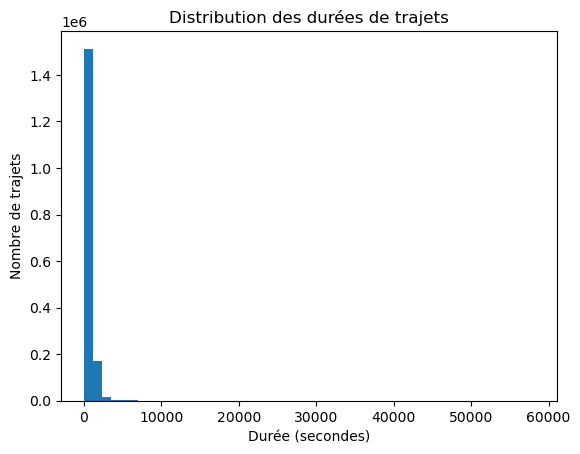

In [ ]:
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

df = df.withColumn("coords", F.from_json("POLYLINE", "array<array<double>>"))
df = df.withColumn("duration", F.size("coords") * 15)

pdf = df.select("duration").toPandas()

plt.hist(pdf["duration"], bins=50)
plt.title("Distribution des durées de trajets")
plt.xlabel("Durée (secondes)")
plt.ylabel("Nombre de trajets")
plt.show()

ANALYSE ET prise de decision  :
- la majorite des trajet sont courts dure quelques minutes 
- donc on peut ajouter dans l injecteur d annomalie l evenement ou il y a des trajets qui durent long temp pour
  tester comment le systeme va reagir  

VISUALISATION 2 —DEMANDE PAR TYPE DE JOUR

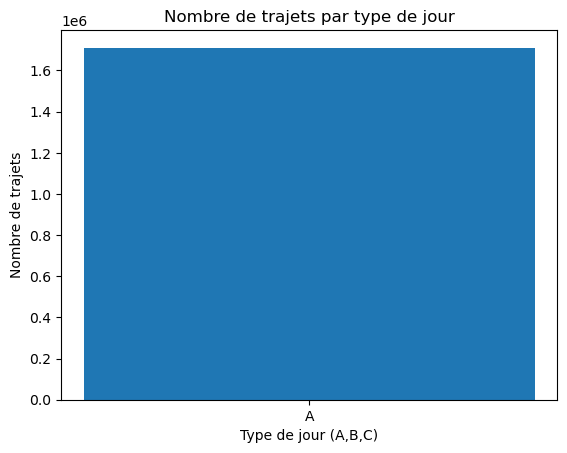

In [ ]:
import matplotlib.pyplot as plt

result = df.groupBy("DAY_TYPE").count().orderBy("DAY_TYPE").collect()

labels = [row["DAY_TYPE"] for row in result]
values = [row["count"] for row in result]

plt.bar(labels, values)
plt.title("Nombre de trajets par type de jour")
plt.xlabel("Type de jour (A,B,C)")
plt.ylabel("Nombre de trajets")
plt.show()

Le dataset contient uniquement des trajets réalisés durant des jours normaux (type A), 
et ne contient pas de données pour les jours spéciaux (fêtes) ni les jours précédant ces événements.

deduction 1:
donc dataset non complet et on a un manque de diversité cela implique que  le système ne peut pas 
apprendre les comportements en jours spéciaux
donc :
Cela justifie l’utilisation d’un injecteur d’anomalies pour simuler des événements comme les jours de fête, 
les pics de demande ou les conditions exceptionnelles.

Le nombre élevé de trajets pendant les jours normaux indique une forte activité quotidienne, ce qui peut entraîner des problèmes de congestion ce qui prouve la necessite de l organisation de la mobilité.

VISUALISATION 3—  RÉPARTITION DES TRAJETS PAR TAXI

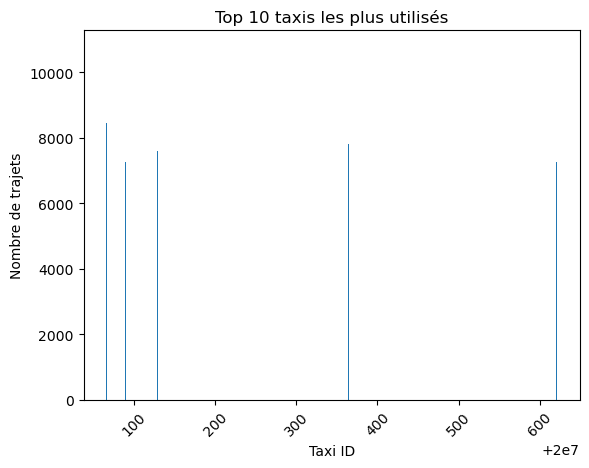

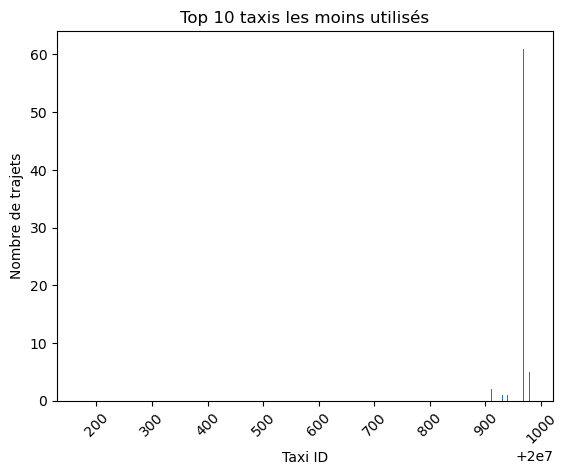

In [ ]:
df_counts = df.groupBy("TAXI_ID").count()
top_taxis = df_counts.orderBy(F.desc("count")).limit(10)
low_taxis = df_counts.orderBy(F.asc("count")).limit(10)
data = top_taxis.collect()

taxi_ids = [row["TAXI_ID"] for row in data]
counts = [row["count"] for row in data]

import matplotlib.pyplot as plt

plt.bar(taxi_ids, counts)
plt.title("Top 10 taxis les plus utilisés")
plt.xlabel("Taxi ID")
plt.ylabel("Nombre de trajets")
plt.xticks(rotation=45)
plt.show()
data = low_taxis.collect()

taxi_ids = [row["TAXI_ID"] for row in data]
counts = [row["count"] for row in data]

plt.bar(taxi_ids, counts)
plt.title("Top 10 taxis les moins utilisés")
plt.xlabel("Taxi ID")
plt.ylabel("Nombre de trajets")
plt.xticks(rotation=45)
plt.show()

- on observe que certains taxis sont très utilisés tandis que d’autres ont très peu de trajets
- Donc pour eviter se desequillibre on peut favoriser la proposition des taxis moins utilise
- quand l utilisateur demande au chatbot donne moi la liste des taxis systeme lui affiche en premier ses derniers
- on  améliorerant l’algorithme de matching (sert a associer un client avec un taxi disponible)  en leur donnant plus de priorité afin d’assurer une répartition équitable des trajets.

VISUALISATION 4 — PRÉFÉRENCE DES UTILISATEURS

VISUALISATION 5 — Distribution des types de courses

In [ ]:
plt.figure(figsize=(6,4))
df["CALL_TYPE"].value_counts().plot(kind="bar")
plt.title("Call Type Distribution")
plt.xlabel("Call Type")
plt.ylabel("Count")
plt.show()

Le type A correspond aux courses commandées via un centre d’appel.
Le type B correspond aux courses prises depuis une station de taxi.
Le type C correspond aux taxis arrêtés directement dans la rue.

 On observe que le type B est le plus fréquent, ce qui signifie que la majorité des clients prennent un taxi depuis une station.
 -> ce qui indique un usage important des points fixes dans la ville.

VISUALISATION 6 — Nombre de trajets par heure

In [ ]:
plt.figure(figsize=(10,5))
df.groupby("hour").size().plot()
plt.title("Trips per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

On observe que le nombre de trajets est faible la nuit, puis augmente fortement le matin avec un pic autour de 8h–9h. Il y a aussi un second pic l’après-midi vers 13h–15h, puis le nombre de trajets diminue progressivement le soir.

Ces résultats permettent d’identifier les heures de pointe, ce qui peut aider à optimiser la distribution des taxis dans la ville et améliorer la gestion du trafic.

VISUALISATION 7 — Nombre de trajets par jour

In [ ]:
plt.figure(figsize=(10,5))
df["day_name"].value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar")
plt.title("Trips per Day")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.show()

On observe que les trajets sont plus nombreux en début de semaine (lundi, mardi, mercredi) (Les jours de travail), puis diminuent vers le week-end.

In [ ]:
Cela montre que l’activité des taxis est liée aux déplacements professionnels et diminue pendant les jours de repos.


morale :

- ce que on a  appris est l exploration et analyse de dataset aide a decouvrir les probleme 
pour savoir facilement les solutions et donc fonctionnalites = ici on se sent vraiment de notre role comme data engineering (data → décision → amélioration du système)
- comprendre l architecture de projet constitue la base nous a pris un  jour tous entier
